# **Lectura y preparación de datos**

**Lectura del conjunto de datos: Tienda de comestibles**

- Cada fila del conjunto de datos se corresponde con la compra realizada por un cliente.
- Los artículos comprados por un cliente se dan como una lista de artículos.


Nomenclatura:
 - **Transacciones:** Patrones (filas)
 - **Items:** Elementos contenidos en cada transacción.
 - **ItemSet:** Conjunto de items

In [1]:
# Dataset de ejemplo
clientes= [ ['Leche', 'Pan', 'Mantequilla'], # Transacción 1
            ['Cereales', 'Pan', 'Manzanas'], # Transacción 2
            ['Leche', 'Cereales', 'Pan', 'Manzanas'], # Transacción 3
            ['Cereales', 'Manzanas'] # Transacción 4
          ]

print('Hay {} transacciones (compras de clientes)'.format(len(clientes)))

# Variable para almacenar todos los artículos
conjunto_articulos= set()

# Pasamos por todos los clientes y sus artículos, y los añadimos sin repetir
for articulos_cliente in clientes:
  for articulo in articulos_cliente:
    articulo= articulo.upper() # Mayúsculas
    conjunto_articulos.add(articulo)

# Cogemos todos los artículos en una lista y los ordenamos
lista_articulos= list(conjunto_articulos)
lista_articulos.sort()

print('Hay {} items (artículos), que son:\n{}'.format(len(lista_articulos), lista_articulos))



Hay 4 transacciones (compras de clientes)
Hay 5 items (artículos), que son:
['CEREALES', 'LECHE', 'MANTEQUILLA', 'MANZANAS', 'PAN']


**Codificación One-Hot de los datos**

In [2]:
import numpy as np


# Asignamos un índice a cada artículo y asociamos su nombre con el índice.
# Para ello, hacemos uso de un diccionario
items_code= { name : index for index, name in enumerate(lista_articulos) }
code_items= { items_code[item] : item for item in items_code.keys()}
print('Los artículos con índices asignados:\n{}'.format(items_code))
print('\nLos índices con artículos asignados:\n{}'.format(code_items))

# Creación de la tabla de #clientes x # artículos
dataset= np.zeros((len(clientes), len(lista_articulos)), dtype=int)

# Asignamos 1 a las celdas de clientes que han comprado un artículo
for cl_idx, articulos_cliente in enumerate(clientes):
  for articulo in articulos_cliente:
    articulo= articulo.upper() # Mayúsculas

    # Ponemos la celda del índice del artículo para el cliente actual en 1
    dataset[cl_idx, items_code[articulo]]= 1

# Ejemplo para el primer cliente
print('\nPrimer cliente (raw): ', clientes[0])
print('Primer cliente (OneHot):\n{}  (TOTAL: {} artículos)'.format(dataset[0], np.sum(dataset[0])))


Los artículos con índices asignados:
{'CEREALES': 0, 'LECHE': 1, 'MANTEQUILLA': 2, 'MANZANAS': 3, 'PAN': 4}

Los índices con artículos asignados:
{0: 'CEREALES', 1: 'LECHE', 2: 'MANTEQUILLA', 3: 'MANZANAS', 4: 'PAN'}

Primer cliente (raw):  ['Leche', 'Pan', 'Mantequilla']
Primer cliente (OneHot):
[0 1 1 0 1]  (TOTAL: 3 artículos)


# **Métricas**

**Soporte:** Se define como la tasa entre el número de transacciones que contienen un item (o conjunto de items) en el total de transacciones existentes.

Support is defined as the ratio of the number of times an item occurs in the transactions to the total number of transactions. This metric thus defines the probability of the occurrence of each individual item in the transactions. The same logic can be extended to itemsets. Se calcula como:

$S(I_A)= {{Occ(I_A)}\over{N}}$

donde:

- $I_A$ es un item o itemset.
- #Occ(I_A)$ es el número de transacciones donde aparece $I_A$.
- $N$ es el total de transacciones existentes

**Confianza**: Se aplica a reglas de asociación. La confianza de una regla $X\rightarrow Y$ se define como la tasa entre el número de transacciones que contienen a $X$ y a $Y$ frente al número de transacciones que contienen $X$. Se calcula como:

$Conf(X\rightarrow Y)= {{Occ([X, Y])}\over{Occ(X)}}$

**Implementación del soporte:**

In [3]:
# Cálculo del soporte de un Item/Itemset dado como una lista de índices (columnas)
#   X: Dataset codificado OneHot
#   IS: Lista de índices entre 0 y X.shape[1]-1 (incluidos)
def Support(X, IS):
  N= len(X)
  subset= set(range(len(X)))

  for item in IS:

    aparece_en= set(np.where(X[:, item]==1)[0].tolist())
    subset= subset.intersection(aparece_en)

  occ= len(subset)
  support= occ/N
  return support


In [4]:
# Ejemplo de uso con el primer ítem
articulo= lista_articulos[0]
codigo= items_code[articulo]
print('Indice de {}: {}'.format(articulo, codigo))

occ= np.sum(dataset[:, codigo])
print('Hay {} transacciones del total {} con {}'.format(occ, len(dataset), articulo ))
print('occ/N= {}'.format(occ/len(dataset)))
print('El soporte es {}'.format(Support(dataset, [codigo])))


# Ejemplo con leche y pan
articulos= ['PAN', 'LECHE']
codigos= [items_code[articulo] for articulo in articulos]
print('\nIndices de {}: {}'.format(articulos, codigos))

occ_bread= np.sum(dataset[:, codigos[0]])
print('Hay {} transacciones del total {} con {}'.format(occ_bread, len(dataset), articulos[0] ))
occ_milk= np.sum(dataset[:, codigos[1]])
print('Hay {} transacciones del total {} con {}'.format(occ_milk, len(dataset), articulos[1] ))
occ= np.sum( dataset[:, codigos[0]]*dataset[:, codigos[1]] )
print('Hay {} transacciones del total {} con {}'.format(occ, len(dataset), articulos ))
print('occ/N= {}'.format(occ/len(dataset)))
print('El soporte es {}'.format(Support(dataset, codigos)))






Indice de CEREALES: 0
Hay 3 transacciones del total 4 con CEREALES
occ/N= 0.75
El soporte es 0.75

Indices de ['PAN', 'LECHE']: [4, 1]
Hay 3 transacciones del total 4 con PAN
Hay 2 transacciones del total 4 con LECHE
Hay 2 transacciones del total 4 con ['PAN', 'LECHE']
occ/N= 0.5
El soporte es 0.5


**Implementación de la confianza:**


In [5]:
# Calcula la confianza de una regla antecedent -> consequent
#  X: El conjunto de datos (codificado OneHot)
#  antecedent: Lista de índices de items (itemset)
#  consequent: Lista de índices de ítems en consecuente
def Confidence(X, antecedent, consequent):

  N= len(X)
  subset= set(range(len(X)))

  # Calculamos Occ(antecedent)
  for item in antecedent:
    aparece_en= set(np.where(X[:, item]==1)[0].tolist())
    subset= subset.intersection(aparece_en)

  occAntecedent= len(subset)

  # Seguimos calculando Occ(antecedent,consequent)
  for item in consequent:
    aparece_en= set(np.where(X[:, item]==1)[0].tolist())
    subset= subset.intersection(aparece_en)

  occRule= len(subset)

  confidence= occRule/occAntecedent
  return confidence



In [6]:
# Ejemplo: Regla pan -> leche
articulos= ['PAN', 'LECHE']
codigos= [items_code[articulo] for articulo in articulos]
print('\nIndices de {}: {}'.format(articulos, codigos))

c1= Confidence(dataset, [codigos[0]], [codigos[1]])
print('La confianza de {}->{} es: {}'.format(articulos[0], articulos[1], c1))


# Ejemplo: Regla leche entera-> pan blanco
c2= Confidence(dataset, [codigos[1]], [codigos[0]])
print('La confianza de {}->{} es: {}'.format(articulos[1], articulos[0], c2))





Indices de ['PAN', 'LECHE']: [4, 1]
La confianza de PAN->LECHE es: 0.6666666666666666
La confianza de LECHE->PAN es: 1.0


# **Algoritmo APriori**

La extracción de reglas de asociación, con el algoritmo APriori, tiene dos pasos:


```
1. (Algoritmo APriori) Encontrar todos los itemsets frecuentes:
  1.1. Obtener ítems frecuentes (cuya ocurrencia es mayor o igual a un umbral de soporte)
  1.2. Obtener itemsets frecuentes:
    1.2.1. Obtener itemsets candidatos desde items frecuentes.
    1.2.2. Poda de resultados para obtener itemsets frecuentes.
    
2. (Algoritmo de extracción) Extraer reglas de asociación desde los itemsets frecuentes
  2.0. Reglas= {}
  2.1. Para cada itemset frecuente:
    2.1.1. Para cada item en el itemset
      2.1.1.1. X=itemset\{item}
      2.1.1.2. Calcular confianza de X->item e insertarla en Reglas si procede.
      2.1.1.3. Calcular confianza de item->X e insertarla en Reglas si procede.
  
```

**Estudio de soportes.**

Un correcto análisis de datos previo puede ayudar a seleccionar un buen valor para el soporte.


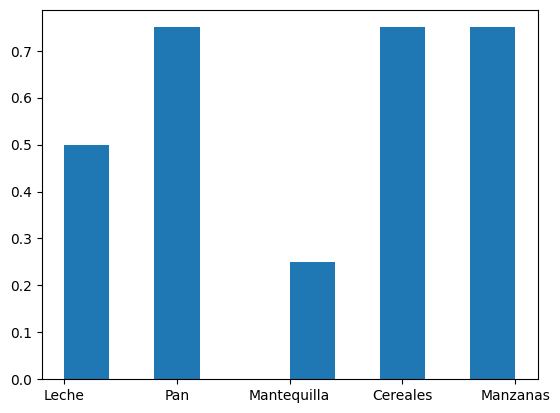

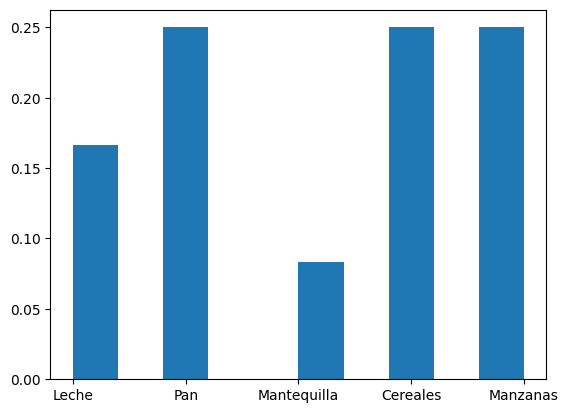

In [7]:
from itertools import chain
import matplotlib.pyplot as plt

items= list(chain.from_iterable(clientes))

# Histograma de items normalizado al número de clientes (transacciones)
weights = np.ones(len(items))/len(clientes)
plt.hist(items, weights=weights)
plt.show()



# Histograma de items normalizado al número de items
weights = np.ones(len(items))/len(items)
plt.hist(items, weights=weights)
plt.show()


In [8]:
from itertools import combinations


# Implementación del algoritmo APriori
#   X: Conjunto de datos (OneHot)
#   min_support: Soporte mínimo aceptadp
def APriori(X, min_support):

  # Obtener todos los items y su soporte
  supports= {}
  items= set(np.arange(X.shape[1]))
  for item in items:
    s= Support(X, [item])

    # Nos quedamos sólo con los que tengan
    #  soporte por encima del umbral
    if s >= min_support:
      supports[tuple( [item] )]= s


  # Nos quedamos con los ítems individuales
  #  con soporte por encima del umbral
  #  y creamos una lista con los itemsets
  #  ordenada por número de items en el itemset
  items= list(supports.keys())
  support_levels= [supports]


  # Iteramos para construir itemsets con itemset_len items
  for itemset_len in range(2,len(items)):

    # Soportes para los itemsets de tamaño itemset_len
    supports= {}

    # Hacemos todas las combinaciones posibles de items
    #  de longitud itemset_len
    for itemset in combinations(items, itemset_len):

      # Calculamos soporte del itemset
      itemset_list= []
      for elm in itemset:
        itemset_list.extend(elm)

      current_support= Support(X, itemset)

      # Si supera el umbral, nos quedamos con él
      if current_support >= min_support:
        supports[tuple(itemset_list)]= current_support

    # Si no hay itemsets frecuentes, salir
    if not supports:
      break
    else:
      # En otro caso, los añadimos a la lista de itemsets
      support_levels.append(supports)

  # Devolvemos la lista de itemsets frecuentes
  return support_levels


Ejemplo: Extracción de itemsets frecuentes con umbral de soporte mínimo indicado.

In [9]:

min_support= 0.5 # Soporte mínimo de los itemsets
itemsets= APriori(dataset, min_support) # Algoritmo de extracción de itemsets frecuentes

print('He encontrado los siguientes itemsets:')
for i, itemset_level in enumerate(itemsets):
  print('\tITEMSETS DE TAM. {}:'.format(i+1))
  for itemset in itemset_level:
    itemset_listnames= [code_items[itemset[idx]] for idx in range(len(itemset))]
    print('\t\t{} -> supp. {}'.format(itemset_listnames, itemset_level[itemset]))

He encontrado los siguientes itemsets:
	ITEMSETS DE TAM. 1:
		['CEREALES'] -> supp. 0.75
		['LECHE'] -> supp. 0.5
		['MANZANAS'] -> supp. 0.75
		['PAN'] -> supp. 0.75
	ITEMSETS DE TAM. 2:
		['CEREALES', 'MANZANAS'] -> supp. 0.75
		['CEREALES', 'PAN'] -> supp. 0.5
		['LECHE', 'PAN'] -> supp. 0.5
		['MANZANAS', 'PAN'] -> supp. 0.5
	ITEMSETS DE TAM. 3:
		['CEREALES', 'MANZANAS', 'PAN'] -> supp. 0.5


# **Extracción de reglas**

La extracción de reglas de asociación $X\rightarrow Y$ se efectúa desde el conjunto de itemsets frecuentes. Se trata de buscar qué reglas existen entre los componentes de un itemset concreto. Nos quedamos sólo con las reglas que tengan una confianza mínima dada por un umbral.

In [10]:

def extract_rules(itemsets, min_conf):
  assoc_rules = {} # Reglas de asociación (key) y confianza (value)

  for k in range(1, len(itemsets)): # Pasamos por todos los niveles
    k_ary_itemsets= itemsets[k]

    # Pasamos por todos los itemsets frecuentes de tamaño k
    for itemset in k_ary_itemsets:

      for item in itemset:

        # Eliminamos el item que se testea en la regla
        X= list(itemset)
        X.remove(item)
        X = tuple(X)

        # Regla 1: item es antecedente item -> X
        support_itemset= k_ary_itemsets[itemset]
        support_item= itemsets[0][tuple([item])]
        r1_conf = support_itemset/support_item

        # Regla 2: item es consecuente X -> item
        support_X= itemsets[len(X)-1][X]
        r2_conf= support_itemset/support_X

        # Selección de reglas a insertar
        if r1_conf >= min_conf: # La regla r1 supera umbral de confianza
          assoc_rules[ tuple([tuple([item]), X]) ]= r1_conf

        if r2_conf >= min_conf: # La regla r2 supera umbral de confianza
          assoc_rules[ tuple([X, tuple([item])]) ]= r2_conf
  return assoc_rules


Ejemplo: Extracción de reglas

In [11]:
min_conf= 0.5
rules= extract_rules(itemsets, min_conf)

print('HE ENCONTRADO LAS SIGUIENTES REGLAS (con confianza mínima {}):'.format(min_conf))
for rule in rules:
  rule_names= []

  for rule_element in rule:
    ant_con= []
    # Construimos el antecedente/consecuente
    for item_idx in rule_element:
      ant_con.append(code_items[item_idx])
    rule_names.append(ant_con)

  # mostramos la regla
  print('\t{} -> {} , conf.= {}'.format(rule_names[0], rule_names[1], rules[rule]))

HE ENCONTRADO LAS SIGUIENTES REGLAS (con confianza mínima 0.5):
	['CEREALES'] -> ['MANZANAS'] , conf.= 1.0
	['MANZANAS'] -> ['CEREALES'] , conf.= 1.0
	['CEREALES'] -> ['PAN'] , conf.= 0.6666666666666666
	['PAN'] -> ['CEREALES'] , conf.= 0.6666666666666666
	['LECHE'] -> ['PAN'] , conf.= 1.0
	['PAN'] -> ['LECHE'] , conf.= 0.6666666666666666
	['MANZANAS'] -> ['PAN'] , conf.= 0.6666666666666666
	['PAN'] -> ['MANZANAS'] , conf.= 0.6666666666666666
	['CEREALES'] -> ['MANZANAS', 'PAN'] , conf.= 0.6666666666666666
	['MANZANAS', 'PAN'] -> ['CEREALES'] , conf.= 1.0
	['MANZANAS'] -> ['CEREALES', 'PAN'] , conf.= 0.6666666666666666
	['CEREALES', 'PAN'] -> ['MANZANAS'] , conf.= 1.0
	['PAN'] -> ['CEREALES', 'MANZANAS'] , conf.= 0.6666666666666666
	['CEREALES', 'MANZANAS'] -> ['PAN'] , conf.= 0.6666666666666666


# **La biblioteca mlxtend**

La biblioteca **mlxtend** (*machine learning extensions*) contiene utilidades varias para realizar operaciones rutinarias en aprendizaje automático y en ciencia de datos.

En particular, permite **extraer reglas de asociación** con diversos algoritmos.

Instalación de la biblioteca:


In [12]:
!pip install mlxtend

Una vez instalada, podemos leer una introducción a la extracción de reglas de asociación en la documentación de la biblioteca:

<a href="https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/">https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/</a>



La propia biblioteca es capaz de transformar las transacciones a **OneHot** utilizando la clase **TransactionEncoder** (<a href="https://rasbt.github.io/mlxtend/user_guide/preprocessing/TransactionEncoder/">https://rasbt.github.io/mlxtend/user_guide/preprocessing/TransactionEncoder/</a>

Un ejemplo:

In [13]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

print('Listado inicial de transacciones:')
print(clientes)

print('\nTras la transformación con TransactionEncoder:')
te = TransactionEncoder()
dataset = te.fit(clientes).transform(clientes).astype(int)
print(dataset)

print('Podemos pasar el dataset a un Dataframe:')
df= pd.DataFrame(dataset, columns=te.columns_)
df.head(len(clientes))


Listado inicial de transacciones:
[['Leche', 'Pan', 'Mantequilla'], ['Cereales', 'Pan', 'Manzanas'], ['Leche', 'Cereales', 'Pan', 'Manzanas'], ['Cereales', 'Manzanas']]

Tras la transformación con TransactionEncoder:
[[0 1 1 0 1]
 [1 0 0 1 1]
 [1 1 0 1 1]
 [1 0 0 1 0]]
Podemos pasar el dataset a un Dataframe:


,Cereales,Leche,Mantequilla,Manzanas,Pan
0,0,1,1,0,1
1,1,0,0,1,1
2,1,1,0,1,1
3,1,0,0,1,0



El **algoritmo APriori** se encuentra dentro de la biblioteca como una función de la misma (<a href="https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/">https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/</a>


In [14]:
from mlxtend.frequent_patterns import apriori

itemsets= apriori(df, min_support=0.5, use_colnames=True)
itemsets

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.75,(Cereales)
1,0.50,(Leche)
2,0.75,(Manzanas)
3,0.75,(Pan)
4,0.75,"(Manzanas, Cereales)"
5,0.50,"(Pan, Cereales)"
6,0.50,"(Leche, Pan)"
7,0.50,"(Pan, Manzanas)"
8,0.50,"(Pan, Manzanas, Cereales)"


La **generación de reglas** se efectúa mediante la función **association_rules** (<a href="https://rasbt.github.io/mlxtend/api_subpackages/mlxtend.frequent_patterns/#association_rules">https://rasbt.github.io/mlxtend/api_subpackages/mlxtend.frequent_patterns/#association_rules</a>

In [15]:
from mlxtend.frequent_patterns import association_rules

rules= association_rules(itemsets, len(itemsets), metric="confidence", min_threshold=0.5)
rules


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Manzanas),(Cereales),0.75,0.75,0.75,1.000000,1.333333,1.0,0.1875,inf,1.000000,1.000000,1.000000,1.000000
1,(Cereales),(Manzanas),0.75,0.75,0.75,1.000000,1.333333,1.0,0.1875,inf,1.000000,1.000000,1.000000,1.000000
2,(Pan),(Cereales),0.75,0.75,0.50,0.666667,0.888889,1.0,-0.0625,0.75,-0.333333,0.500000,-0.333333,0.666667
3,(Cereales),(Pan),0.75,0.75,0.50,0.666667,0.888889,1.0,-0.0625,0.75,-0.333333,0.500000,-0.333333,0.666667
4,(Leche),(Pan),0.50,0.75,0.50,1.000000,1.333333,1.0,0.1250,inf,0.500000,0.666667,1.000000,0.833333
5,(Pan),(Leche),0.75,0.50,0.50,0.666667,1.333333,1.0,0.1250,1.50,1.000000,0.666667,0.333333,0.833333
6,(Pan),(Manzanas),0.75,0.75,0.50,0.666667,0.888889,1.0,-0.0625,0.75,-0.333333,0.500000,-0.333333,0.666667
7,(Manzanas),(Pan),0.75,0.75,0.50,0.666667,0.888889,1.0,-0.0625,0.75,-0.333333,0.500000,-0.333333,0.666667
8,"(Pan, Manzanas)",(Cereales),0.50,0.75,0.50,1.000000,1.333333,1.0,0.1250,inf,0.500000,0.666667,1.000000,0.833333
9,"(Pan, Cereales)",(Manzanas),0.50,0.75,0.50,1.000000,1.333333,1.0,0.1250,inf,0.500000,0.666667,1.000000,0.833333


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
